# Energy balance, DOP853 distance and BM4 multipliers

Presentation only: no integrator runs here. Load the newly computed `results.npz`; the legacy data are incompatible with these initial conditions and diagnostics.

Physical H varies because the potential depends on time. Conservation is measured by K(t)-K(0), where K=H+kappa. Global errors use particle RMS and absolute maxima, so opposite signed particle defects do not cancel. Absolute balance errors avoid dependence on an arbitrary energy-zero normalization. DOP853 is a numerical reference, not a certified exact solution.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from diagnostics.paths import find_project_root
from diagnostics.dop853_energy_balance_npz import load_energy_balance
from visualization import display_records_table
from visualization.dop853_energy_balance import (
    summary_rows, plot_analysis, plot_mu, mu_summary_rows, plot_paths, trajectory_player)
project_root = find_project_root(Path.cwd())
notebook_directory = project_root / "notebooks/developements/energy/energy_balance_dop853_bm4_gl4_rk4_horizontal_3p_200steps_10saves"
arrays, metadata = load_energy_balance(notebook_directory / 'results.npz')
print(metadata)
print('Saved states:', arrays['times'].size)
columns = (('method', 'Method', None), ('balance_rms', 'Balance RMS', '.4e'),
           ('balance_max', 'Balance max', '.4e'), ('balance_final_rms', 'Final balance RMS', '.4e'),
           ('distance_rms', 'Distance RMS', '.4e'), ('distance_max', 'Distance max', '.4e'),
           ('distance_final_rms', 'Final distance RMS', '.4e'))


{'schema_version': 1, 'config': {'cycles': 200, 'cycle_duration': 1.0, 'steps_per_cycle': 200, 'saves_per_cycle': 10, 'rho': 0.3, 'coupling_frequency': 0.39269908169872414, 'newton_atol': 1e-13, 'newton_rtol': 1e-12, 'newton_max_iterations': 40, 'jacobian_relative_step': 6.0554544523933395e-06, 'reference_rtol': 1e-10, 'reference_atol': 1e-12}, 'potential': {'source_path': 'data/potential/V1/PHI_2.h5', 'magnetic_field': 1.5, 'characteristic_length': 0.06, 'mode_selection': [0, 1], 'interpolation_order': 3}, 'initial_conditions': {'x_fractions': [0.25, 0.5, 0.75], 'y_fraction': 0.5}, 'methods': ['DOP853', 'BM4Implicit', 'GaussLegendre4', 'RK4'], 'distance_convention': 'minimum-image periodic Euclidean', 'energy_diagnostic': 'K=H+kappa; kappa_dot=-partial_t H; kappa(0)=0', 'multiplier_norm': 'infinity norm per particle; endpoint and all-step block statistics'}
Saved states: 2001


## Initial conditions and global analysis

Particle coordinates are fractions (0.25,0.50), (0.50,0.50), (0.75,0.50) of the periodic cell. Tables use trapezoidal time-weighted RMS over saved states. Maxima of energy and distance refer to saved states.

Particle,Initial x,Initial y
1,4.71238898,9.42477796
2,9.42477796,9.42477796
3,14.13716694,9.42477796


Method,Balance RMS,Balance max,Final balance RMS,Distance RMS,Distance max,Final distance RMS
DOP853,2.8479e-06,8.1489e-06,5.3371e-06,0.0000e+00,0.0000e+00,0.0000e+00
BM4Implicit,1.9649e-06,6.1903e-06,3.9896e-06,4.1552e-02,3.6531e-01,1.2397e-01
GaussLegendre4,3.4031e-05,1.2781e-04,2.8525e-05,4.9389e-01,2.9028e+00,7.1736e-01
RK4,6.8545e-05,1.8585e-04,1.0437e-04,1.5881e+00,7.9381e+00,4.4691e+00


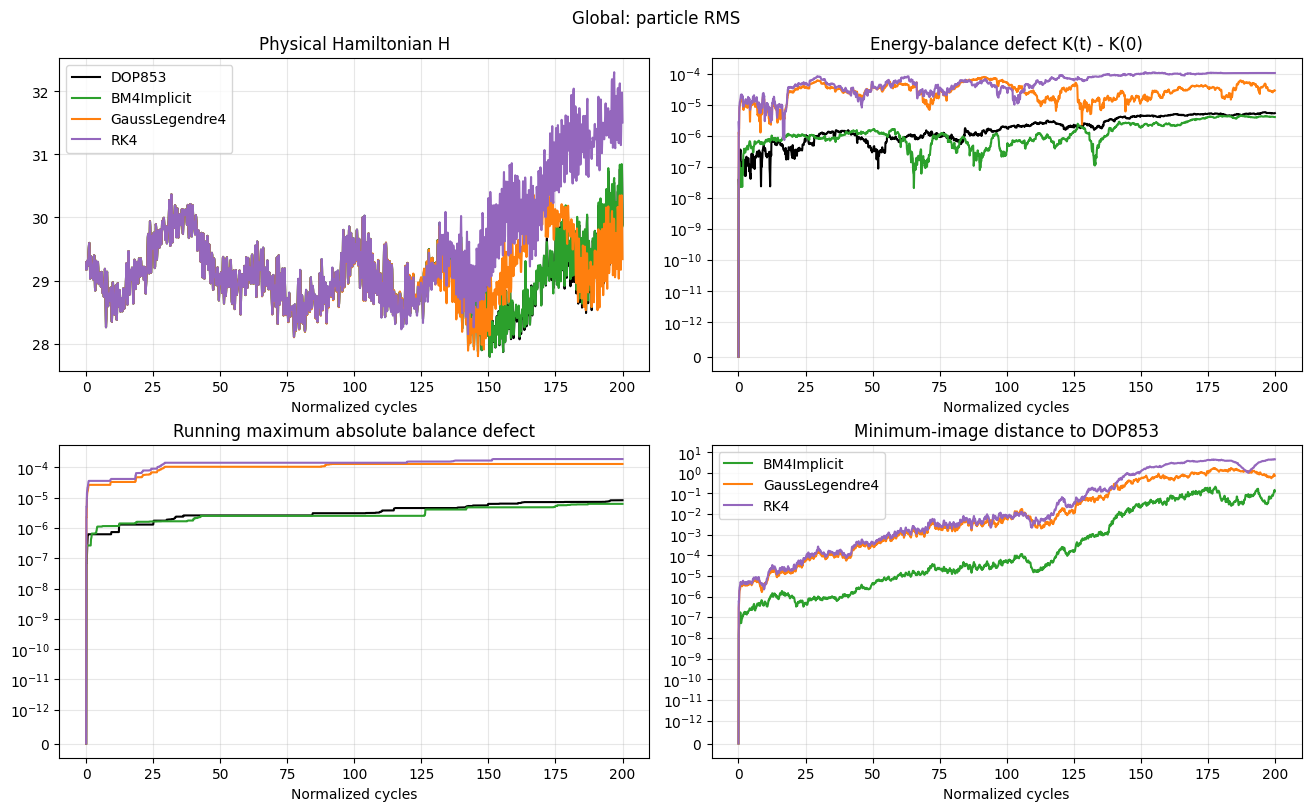

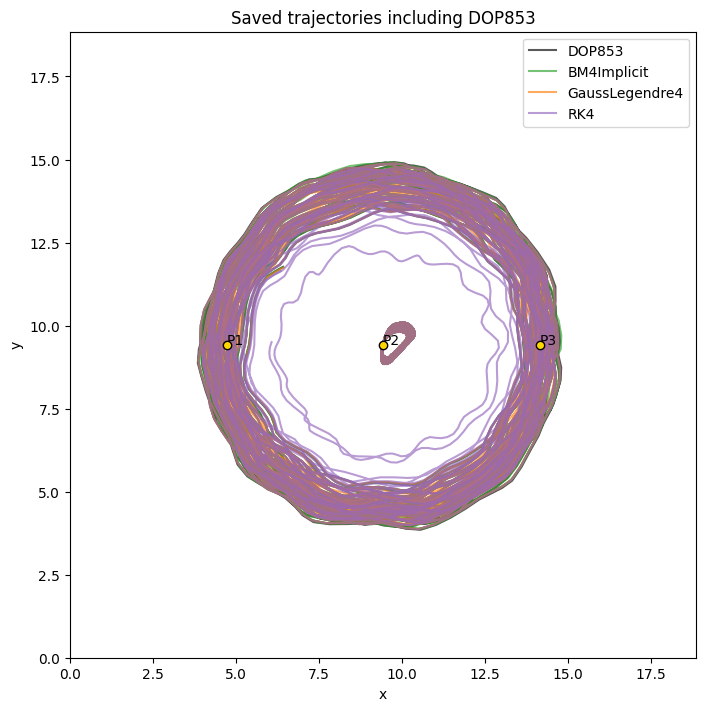

In [2]:
z0 = arrays['initial_state']
display_records_table(tuple(SimpleNamespace(particle=p+1, x=z0[p], y=z0[p+3]) for p in range(3)),
    columns=(('particle', 'Particle', 'd'), ('x', 'Initial x', '.8f'), ('y', 'Initial y', '.8f')))
display_records_table(tuple(SimpleNamespace(**r) for r in summary_rows(arrays)), columns=columns)
plot_analysis(arrays)
plt.show()
plot_paths(arrays)
plt.show()

## Separate particle analyses

Each particle gets its own summary, physical Hamiltonian, signed energy-balance defect, running absolute defect, distance history and trajectory plot including DOP853.

### Particle 1

Method,Balance RMS,Balance max,Final balance RMS,Distance RMS,Distance max,Final distance RMS
DOP853,3.4595e-06,7.0703e-06,5.4541e-06,0.0000e+00,0.0000e+00,0.0000e+00
BM4Implicit,2.4380e-06,4.9419e-06,4.1638e-06,5.6674e-04,3.7654e-03,1.4471e-03
GaussLegendre4,2.8607e-05,8.7923e-05,4.7442e-05,1.3027e-02,9.6817e-02,2.6260e-02
RK4,2.7084e-05,8.2225e-05,9.2970e-06,2.9966e-02,1.5946e-01,1.5051e-01


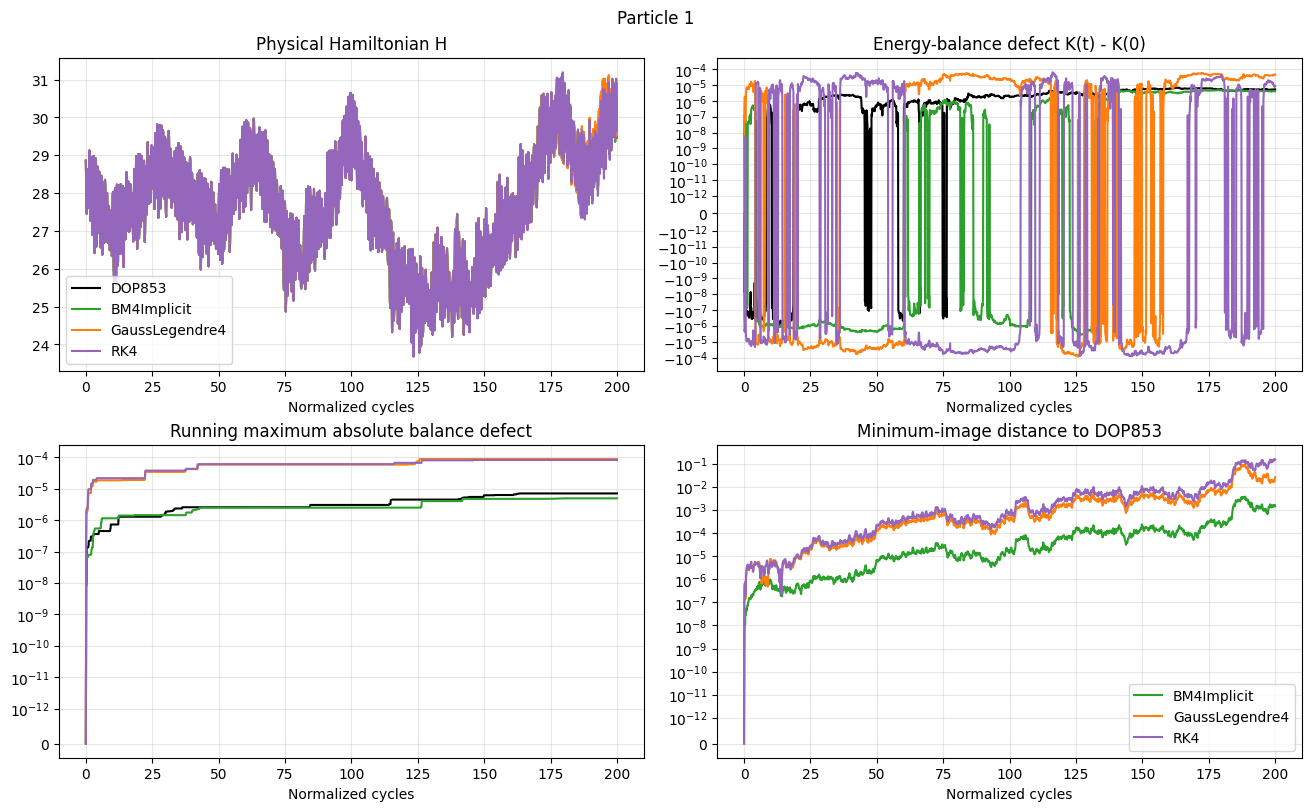

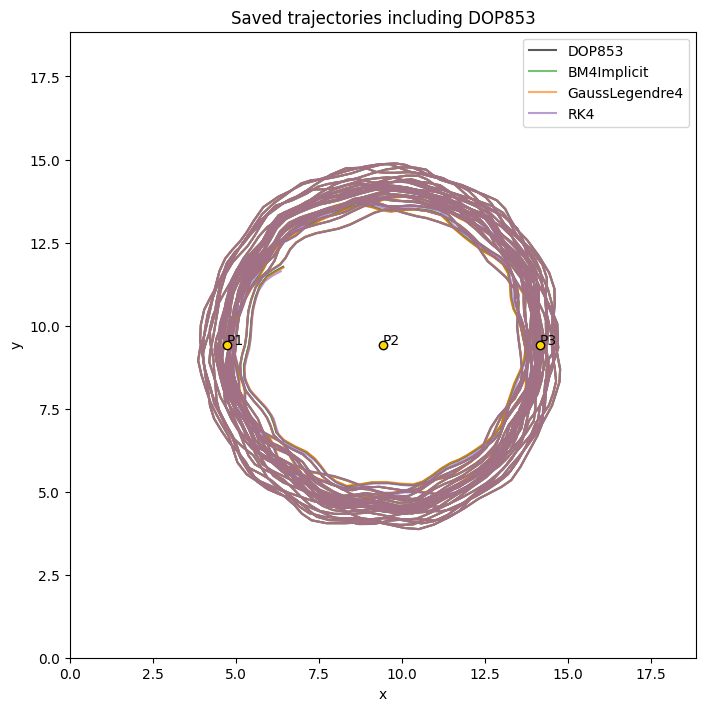

### Particle 2

Method,Balance RMS,Balance max,Final balance RMS,Distance RMS,Distance max,Final distance RMS
DOP853,3.0573e-09,5.0822e-09,1.9965e-09,0.0000e+00,0.0000e+00,0.0000e+00
BM4Implicit,5.2776e-10,8.7525e-10,3.8813e-10,8.9895e-09,2.7612e-08,1.0823e-08
GaussLegendre4,1.3067e-08,2.0826e-08,1.9221e-08,2.9821e-08,1.0643e-07,5.0829e-08
RK4,2.4302e-08,3.9409e-08,3.9331e-08,3.3741e-08,1.1919e-07,6.7324e-08


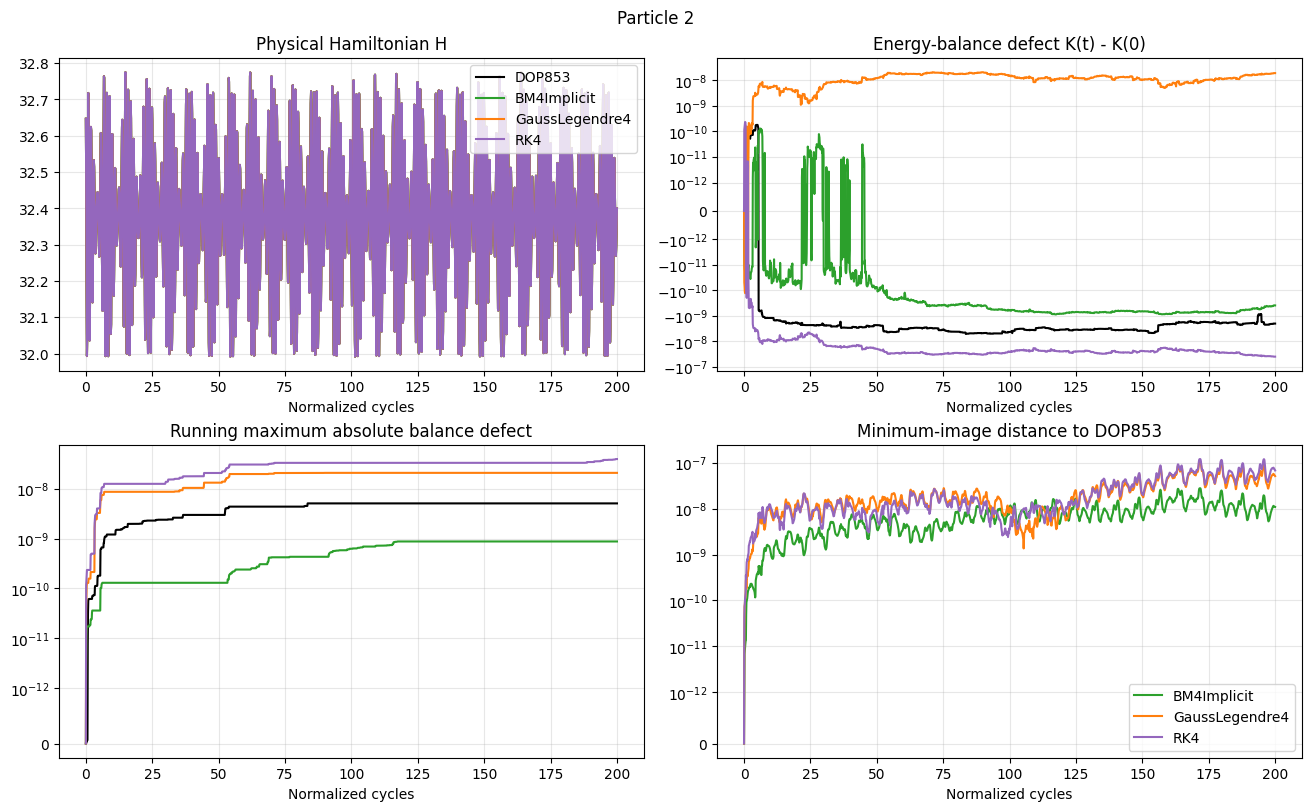

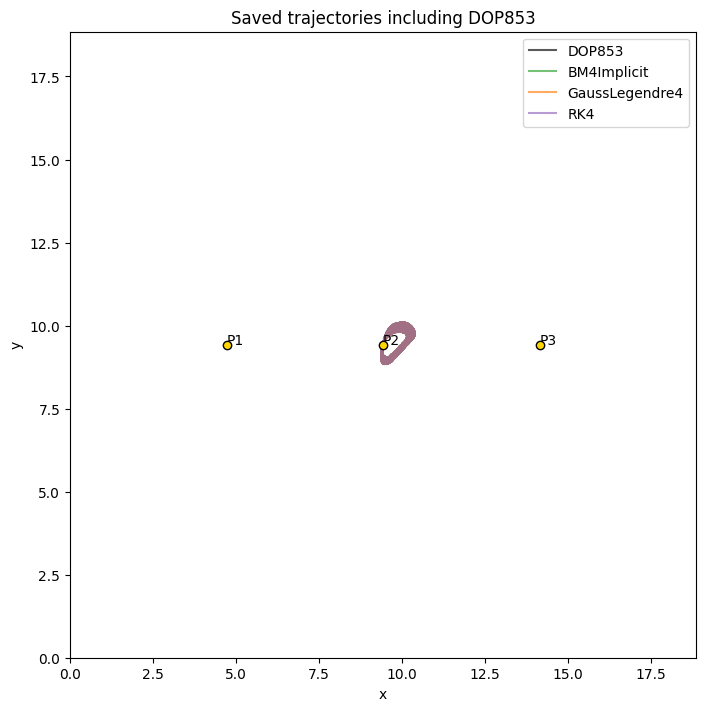

### Particle 3

Method,Balance RMS,Balance max,Final balance RMS,Distance RMS,Distance max,Final distance RMS
DOP853,3.5162e-06,8.1489e-06,7.4637e-06,0.0000e+00,0.0000e+00,0.0000e+00
BM4Implicit,2.3746e-06,6.1903e-06,5.5148e-06,7.1968e-02,3.6531e-01,2.1472e-01
GaussLegendre4,5.1535e-05,1.2781e-04,1.3792e-05,8.5534e-01,2.9028e+00,1.2422e+00
RK4,1.1559e-04,1.8585e-04,1.8053e-04,2.7505e+00,7.9381e+00,7.7393e+00


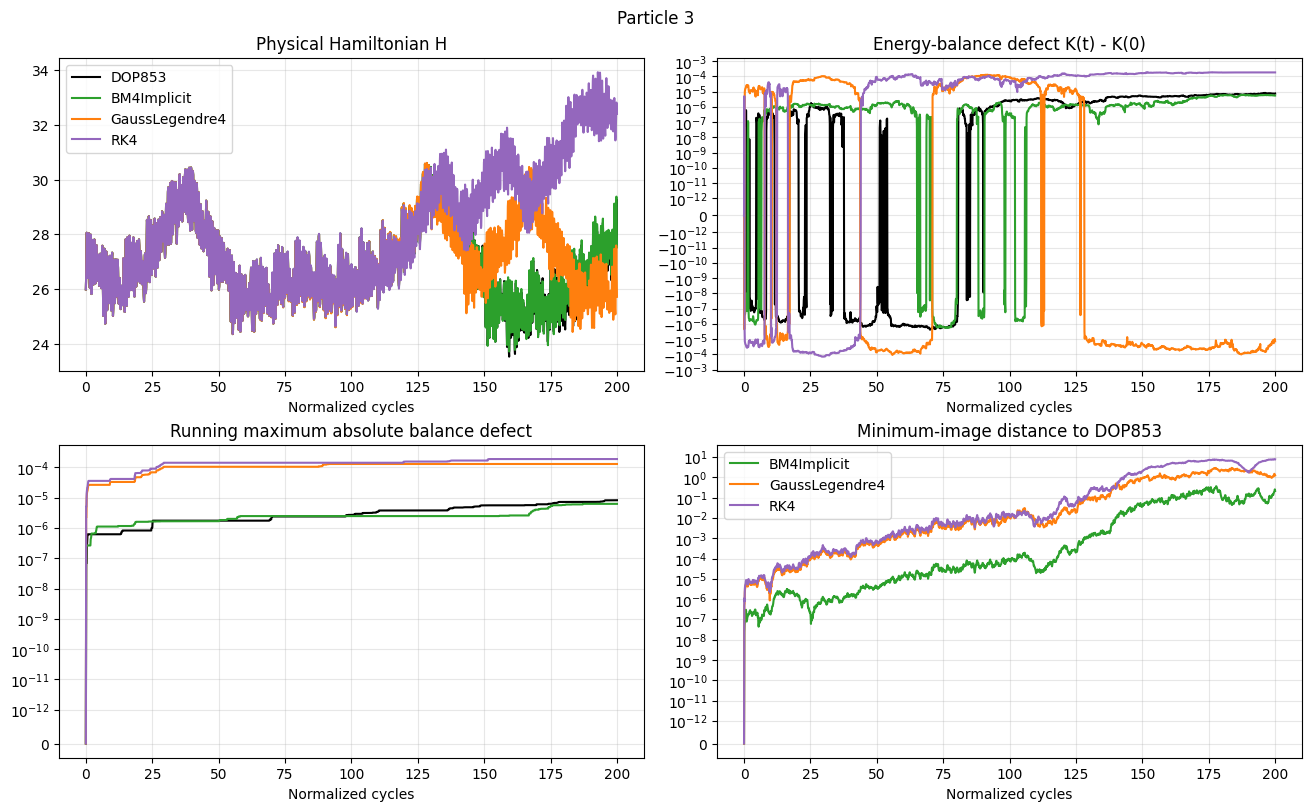

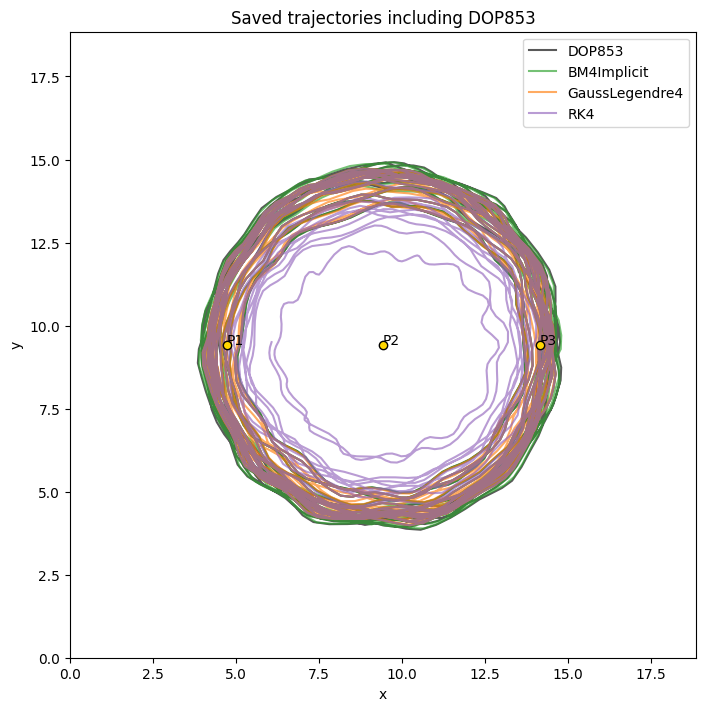

In [3]:
for particle in range(3):
    display(Markdown(f"### Particle {particle+1}"))
    display_records_table(tuple(SimpleNamespace(**r) for r in summary_rows(arrays, particle)), columns=columns)
    plot_analysis(arrays, particle)
    plt.show()
    plot_paths(arrays, particle)
    plt.show()

## BM4 implicit multiplier

For particle p, the norm is max(abs(mu_x,p),abs(mu_y,p)); the global norm is the maximum over particles. Curves show endpoint norms and block peaks. Summary mean/RMS/max use every accepted step, retaining peaks between saved times. The zero initial slot is excluded.

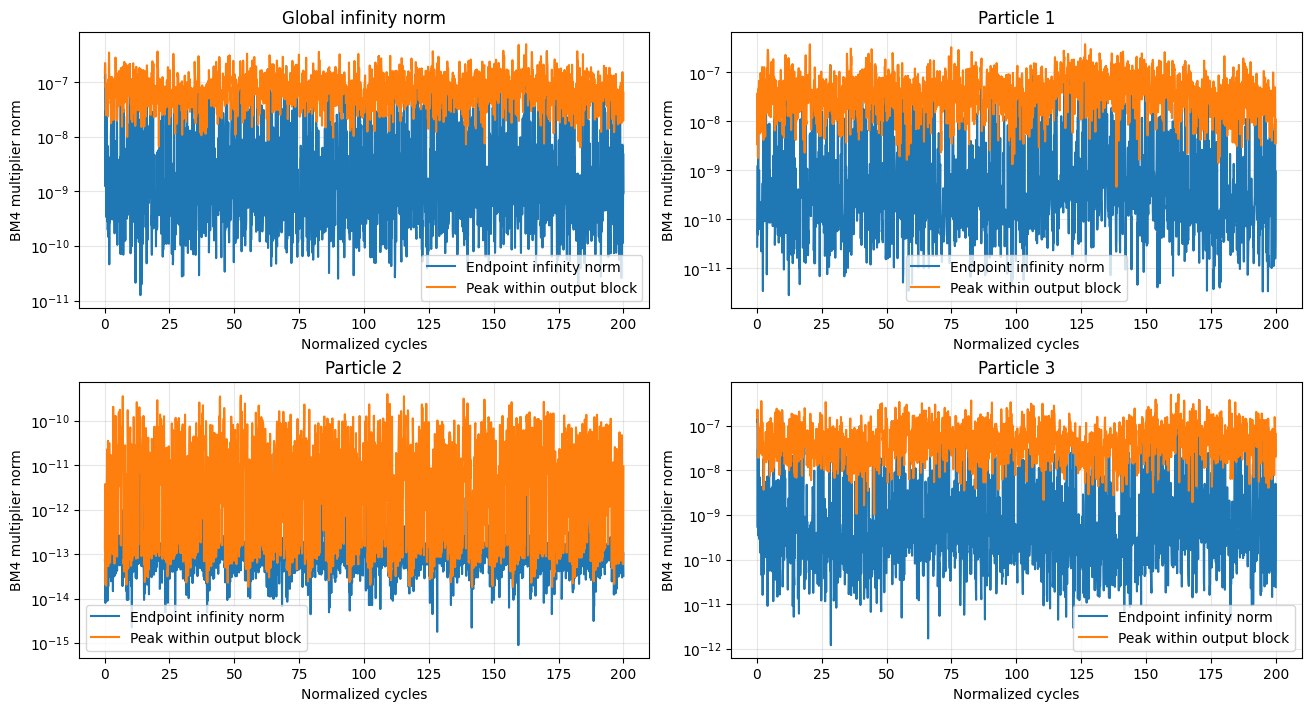

Scope,Mean norm,RMS norm,Peak norm,Final norm
Global,1.1833e-08,3.0210e-08,5.0227e-07,9.3409e-10
Particle 1,5.6502e-09,1.9367e-08,3.7165e-07,9.3409e-10
Particle 2,1.2618e-12,1.1079e-11,3.9954e-10,3.2496e-14
Particle 3,6.8963e-09,2.3448e-08,5.0227e-07,2.4197e-11


Global peak multiplier norm: 5.022690402456835e-07


In [4]:
plot_mu(arrays)
plt.show()
display_records_table(tuple(SimpleNamespace(**r) for r in mu_summary_rows(arrays)),
    columns=(('particle', 'Scope', None), ('mean', 'Mean norm', '.4e'),
             ('rms', 'RMS norm', '.4e'), ('maximum', 'Peak norm', '.4e'), ('final', 'Final norm', '.4e')))
print('Global peak multiplier norm:', np.max(arrays['BM4Implicit.mu_max'][:, 1:]))

## Selectable trajectory animation

All 2,001 saved frames are available. Toggle any method, including DOP853; use the timeline, playback speed and trail length controls. Particle identity uses marker shape. At 10 fps, one normalized cycle plays per second. The standalone HTML also works without a Python kernel; trust the notebook to enable embedded JavaScript.

In [5]:
player = trajectory_player(arrays)
(notebook_directory / 'trajectories.html').write_text(player.data, encoding='utf-8')
display(player)

## Computed conclusions

Conservation and trajectory agreement are separate rankings. A small balance defect does not guarantee small distance to DOP853.

In [6]:
for particle in (None, 0, 1, 2):
    rows = [r for r in summary_rows(arrays, particle) if r['method'] != 'DOP853']
    best_balance = min(rows, key=lambda r: r['balance_rms'])
    best_distance = min(rows, key=lambda r: r['distance_rms'])
    scope = 'Global' if particle is None else f'Particle {particle+1}'
    display(Markdown(f"**{scope}:** smallest balance RMS: {best_balance['method']} "
                     f"({best_balance['balance_rms']:.4e}); smallest distance RMS: "
                     f"{best_distance['method']} ({best_distance['distance_rms']:.4e})."))

**Global:** smallest balance RMS: BM4Implicit (1.9649e-06); smallest distance RMS: BM4Implicit (4.1552e-02).

**Particle 1:** smallest balance RMS: BM4Implicit (2.4380e-06); smallest distance RMS: BM4Implicit (5.6674e-04).

**Particle 2:** smallest balance RMS: BM4Implicit (5.2776e-10); smallest distance RMS: BM4Implicit (8.9895e-09).

**Particle 3:** smallest balance RMS: BM4Implicit (2.3746e-06); smallest distance RMS: BM4Implicit (7.1968e-02).